# 5.1.2 Model 2: Random Forest Regressor

Trained on `X_train.csv` (unscaled) since tree-based models don't need feature scaling.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import sys, os
sys.path.append(os.path.dirname(os.path.abspath('__file__')))
from model_utils import evaluate_model, cross_validate_model

MODELLING_DIR = os.path.join("..", "data", "modelling")

X_train = pd.read_csv(os.path.join(MODELLING_DIR, "X_train.csv"))
X_test = pd.read_csv(os.path.join(MODELLING_DIR, "X_test.csv"))
y_train = pd.read_csv(os.path.join(MODELLING_DIR, "y_train.csv"))["price"]
y_test = pd.read_csv(os.path.join(MODELLING_DIR, "y_test.csv"))["price"]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (3004, 51) | X_test: (751, 51)


## Hyperparameter Tuning
A small grid searched with 5-fold CV on the training set only. `y_train` is `log(price)` (Section 3.6), so a plain `neg_root_mean_squared_error` scorer would rank configurations by log-scale RMSE - since `exp()` is a non-linear transform, this does not guarantee the same ranking as RM-scale RMSE, which is this project's primary metric (Section 1.8). To keep the tuning criterion consistent with how models are evaluated everywhere else in this report, `GridSearchCV` uses a custom scorer that converts predictions back to RM before scoring.

In [2]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import KFold

def rm_scale_rmse(y_true_log, y_pred_log):
    y_true_rm = np.exp(y_true_log)
    y_pred_rm = np.exp(y_pred_log)
    return np.sqrt(np.mean((y_true_rm - y_pred_rm) ** 2))

rm_rmse_scorer = make_scorer(rm_scale_rmse, greater_is_better=False)

# Same fold split used by cross_validate_model() (model_utils.py), so the CV score
# GridSearchCV selects on and the second CV report below are directly comparable.
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_leaf": [1, 2, 3, 4],
    "max_features": ["sqrt", 0.5, 1.0],
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    scoring=rm_rmse_scorer,
    cv=cv_splitter,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print(f"Best CV score (RM-scale RMSE): RM {-grid_search.best_score_:,.0f}")


Best params: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV score (RM-scale RMSE): RM 166,693


## 5-fold Cross-Validation
Run on X_train only (X_test stays untouched), using GridSearchCV's selected configuration (`grid_search.best_params_`) - this happens before the final model is retrained or X_test is touched, so all CV-related steps are grouped together ahead of any test-set contact.

In [3]:
cv_results = cross_validate_model(
    RandomForestRegressor(**grid_search.best_params_, random_state=42),
    X_train, y_train, n_splits=5,
)


5-fold CV (mean +/- std):
  RMSE:  RM 166,693 +/- 24,624  (47.4% of median price)
  MAE:   RM 77,661 +/- 3,156
  MAPE:  19.1% +/- 1.5%
  R2:    0.7313 +/- 0.0661


## Train Final Model

`GridSearchCV` was run with its default `refit=True`, so it already retrained a model on the full `X_train` using the best-found configuration (`grid_search.best_estimator_`). That model is reused directly here instead of manually reconstructing and refitting an identical one. `X_test` is not used in any hyperparameter decision - it is touched only once, below, for the final held-out evaluation.

In [4]:
final_params = grid_search.best_params_
model = grid_search.best_estimator_

print("Final params:", final_params)
print("Model ready (reused from GridSearchCV's refit=True).")


Final params: {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'n_estimators': 300}
Model ready (reused from GridSearchCV's refit=True).


## Evaluate
Metrics computed on both train and test sets for Section 6.2's overfitting/underfitting analysis.

In [5]:
train_metrics = evaluate_model(model, X_train, y_train, label="Train")
print()
test_metrics = evaluate_model(model, X_test, y_test, label="Test")


Train RMSE:  RM 72,405  (20.7% of median price)
Train MAE:   RM 29,667
Train MAPE:  6.7%
Train R2:    0.9512



Test RMSE:  RM 180,408  (50.1% of median price)
Test MAE:   RM 78,656
Test MAPE:  16.7%
Test R2:    0.7043


## Feature Importance vs EDA (Section 4.5.2)
Section 4.5.2 ranked Property Size, Bathroom, Parking Lot, and the Has_Gymnasium/Has_Swimming_Pool amenities as the strongest numerical correlates of price, and separately found Property Type (eta-squared 0.424) and State (eta-squared 0.172) to be strong categorical predictors. This checks whether Random Forest's learned importances broadly agree.

In [6]:
importance_table = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 features by importance:")
print(importance_table.head(15))


Top 15 features by importance:
Property Size                     0.539550
Has_Gymnasium                     0.054864
State_Penang                      0.049360
Has_Security                      0.028916
Property Age                      0.028068
# of Floors                       0.025938
PropertyType_Flat                 0.025195
State_Selangor                    0.024293
Total Units                       0.021186
PropertyType_Service_Residence    0.015919
Listed_Facility_Count             0.015788
Bathroom                          0.013397
Parking Lot                       0.012927
PropertyType_Condominium          0.012270
Bedroom                           0.011211
dtype: float64


## Save Trained Model
Saved for the Streamlit prototype (Section 8) to load directly, without retraining.

In [7]:
import joblib
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = os.path.join(MODEL_DIR, "random_forest_model.pkl")
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

Model saved to ..\models\random_forest_model.pkl


## Hyperparameter Sensitivity Visualizations (Diagnostic)

The figures below are diagnostic only - each hyperparameter is swept individually, holding the other three fixed at the values already selected by `GridSearchCV`, and evaluated using 5-fold CV RMSE on `X_train`. They illustrate why the selected configuration is a sound choice; they are not used to select it (see Hyperparameter Tuning above).

## Visualizing the max_depth Trade-off

To understand how `max_depth` affects the bias-variance trade-off, models were retrained at each candidate `max_depth` value (holding `n_estimators=400`, `min_samples_leaf=1`, `max_features=0.5` fixed at their final values) and evaluated using Train RMSE and 5-fold CV RMSE on `X_train` only - `X_test` is not used here. This is a diagnostic visualization only; it illustrates why `GridSearchCV`'s CV-selected `max_depth` is a sound choice, but it is not itself used to pick the hyperparameter.

5-fold CV (mean +/- std):
  RMSE:  RM 189,123 +/- 25,128  (53.8% of median price)
  MAE:   RM 97,506 +/- 4,157
  MAPE:  24.0% +/- 1.3%
  R2:    0.6557 +/- 0.0724


5-fold CV (mean +/- std):
  RMSE:  RM 169,339 +/- 24,193  (48.2% of median price)
  MAE:   RM 81,834 +/- 3,222
  MAPE:  20.2% +/- 1.4%
  R2:    0.7223 +/- 0.0684


5-fold CV (mean +/- std):
  RMSE:  RM 167,340 +/- 24,731  (47.6% of median price)
  MAE:   RM 78,056 +/- 3,200
  MAPE:  19.3% +/- 1.5%
  R2:    0.7291 +/- 0.0674


5-fold CV (mean +/- std):
  RMSE:  RM 167,178 +/- 24,826  (47.5% of median price)
  MAE:   RM 77,748 +/- 3,208
  MAPE:  19.2% +/- 1.5%
  R2:    0.7294 +/- 0.0682


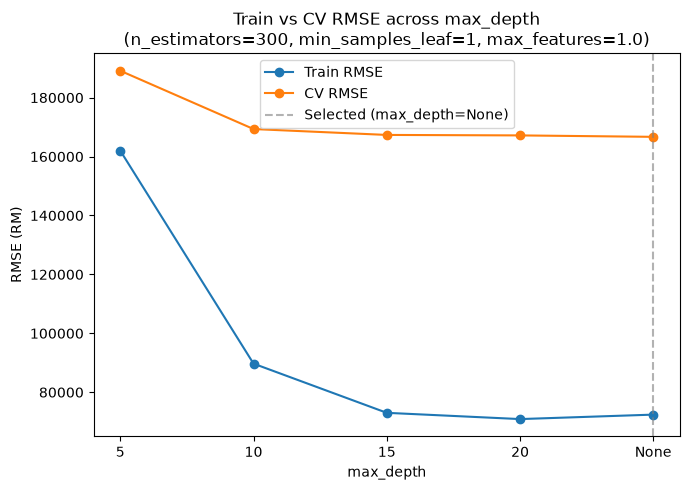

max_depth=5: Train RMSE=RM161,998  CV RMSE=RM189,123
max_depth=10: Train RMSE=RM89,705  CV RMSE=RM169,339
max_depth=15: Train RMSE=RM73,012  CV RMSE=RM167,340
max_depth=20: Train RMSE=RM70,889  CV RMSE=RM167,178
max_depth=None: Train RMSE=RM72,405  CV RMSE=RM166,693


In [8]:
import matplotlib.pyplot as plt

best = grid_search.best_params_
depth_candidates = [5, 10, 15, 20, None]
train_rmse_by_depth = []
cv_rmse_by_depth = []

for d in depth_candidates:
    if d == best["max_depth"]:
        train_rmse_by_depth.append(train_metrics["RMSE"])
        cv_rmse_by_depth.append(cv_results["mean"]["RMSE"])
        continue
    m = RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=d, min_samples_leaf=best["min_samples_leaf"], max_features=best["max_features"], random_state=42)
    m.fit(X_train, y_train)
    train_rmse_by_depth.append(evaluate_model(m, X_train, y_train)["RMSE"])
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=d, min_samples_leaf=best["min_samples_leaf"], max_features=best["max_features"], random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_depth.append(cv["mean"]["RMSE"])

depth_labels = ["None" if d is None else str(d) for d in depth_candidates]
selected_label = "None" if best["max_depth"] is None else str(best["max_depth"])

plt.figure(figsize=(7, 5))
plt.plot(depth_labels, train_rmse_by_depth, marker="o", label="Train RMSE")
plt.plot(depth_labels, cv_rmse_by_depth, marker="o", label="CV RMSE")
plt.axvline(x=depth_labels.index(selected_label), color="grey", linestyle="--", alpha=0.6, label=f"Selected (max_depth={selected_label})")
plt.xlabel("max_depth")
plt.ylabel("RMSE (RM)")
plt.title(f"Train vs CV RMSE across max_depth\n(n_estimators={best['n_estimators']}, min_samples_leaf={best['min_samples_leaf']}, max_features={best['max_features']})")
plt.legend()
plt.tight_layout()
plt.show()

for d, tr, cv_r in zip(depth_labels, train_rmse_by_depth, cv_rmse_by_depth):
    print(f"max_depth={d}: Train RMSE=RM{tr:,.0f}  CV RMSE=RM{cv_r:,.0f}")


## Visualizing the max_features Effect

`max_features` was swept across all three candidate values tested in the grid search (holding `n_estimators=400`, `max_depth=20`, `min_samples_leaf=1` fixed), evaluated using 5-fold CV RMSE on `X_train` only, to compare `sqrt` (~7 of 51 features per split), `0.5` (~26 features), and `1.0` (all 51 features, scikit-learn's regression default).

5-fold CV (mean +/- std):
  RMSE:  RM 195,454 +/- 42,466  (55.6% of median price)
  MAE:   RM 81,850 +/- 6,622
  MAPE:  19.0% +/- 1.4%
  R2:    0.6435 +/- 0.0755


5-fold CV (mean +/- std):
  RMSE:  RM 168,147 +/- 34,022  (47.8% of median price)
  MAE:   RM 77,128 +/- 5,259
  MAPE:  18.7% +/- 1.3%
  R2:    0.7344 +/- 0.0547


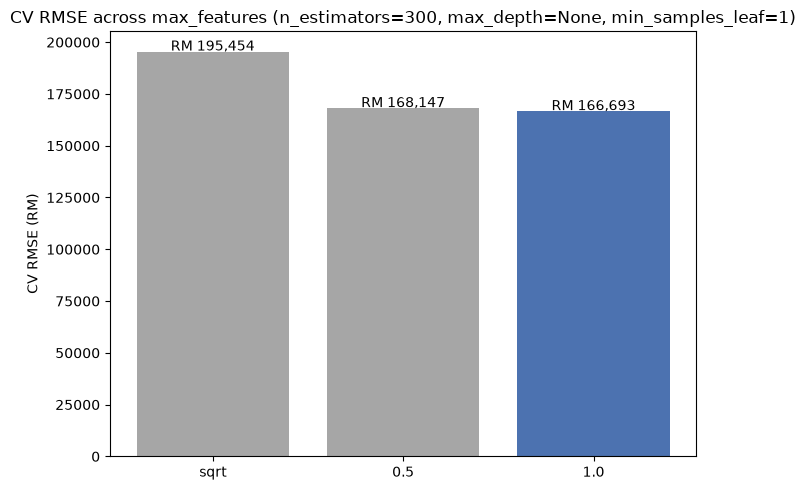

max_features=sqrt: CV RMSE=RM195,454
max_features=0.5: CV RMSE=RM168,147
max_features=1.0: CV RMSE=RM166,693


In [9]:
best = grid_search.best_params_
feature_candidates = ["sqrt", 0.5, 1.0]
cv_rmse_by_feat = []

for f in feature_candidates:
    if f == best["max_features"]:
        cv_rmse_by_feat.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=best["max_depth"], min_samples_leaf=best["min_samples_leaf"], max_features=f, random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_feat.append(cv["mean"]["RMSE"])

colors = ["#4c72b0" if f == best["max_features"] else "#a6a6a6" for f in feature_candidates]

plt.figure(figsize=(7, 5))
plt.bar([str(f) for f in feature_candidates], cv_rmse_by_feat, color=colors)
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across max_features (n_estimators={best['n_estimators']}, max_depth={best['max_depth']}, min_samples_leaf={best['min_samples_leaf']})")
for i, v in enumerate(cv_rmse_by_feat):
    plt.text(i, v + 500, f"RM {v:,.0f}", ha="center")
plt.tight_layout()
plt.show()

for f, r in zip(feature_candidates, cv_rmse_by_feat):
    print(f"max_features={f}: CV RMSE=RM{r:,.0f}")


## Visualizing the n_estimators Effect

To justify the choice of `n_estimators = 400`, models were retrained at each candidate `n_estimators` value (holding `max_depth=20`, `min_samples_leaf=1`, `max_features=0.5` fixed) and evaluated using 5-fold CV RMSE on `X_train` only.

5-fold CV (mean +/- std):
  RMSE:  RM 168,285 +/- 26,106  (47.9% of median price)
  MAE:   RM 78,174 +/- 3,348
  MAPE:  19.3% +/- 1.5%
  R2:    0.7272 +/- 0.0648


5-fold CV (mean +/- std):
  RMSE:  RM 166,831 +/- 24,128  (47.4% of median price)
  MAE:   RM 77,724 +/- 3,098
  MAPE:  19.1% +/- 1.5%
  R2:    0.7316 +/- 0.0622


5-fold CV (mean +/- std):
  RMSE:  RM 167,346 +/- 24,801  (47.6% of median price)
  MAE:   RM 77,709 +/- 3,172
  MAPE:  19.2% +/- 1.5%
  R2:    0.7287 +/- 0.0687


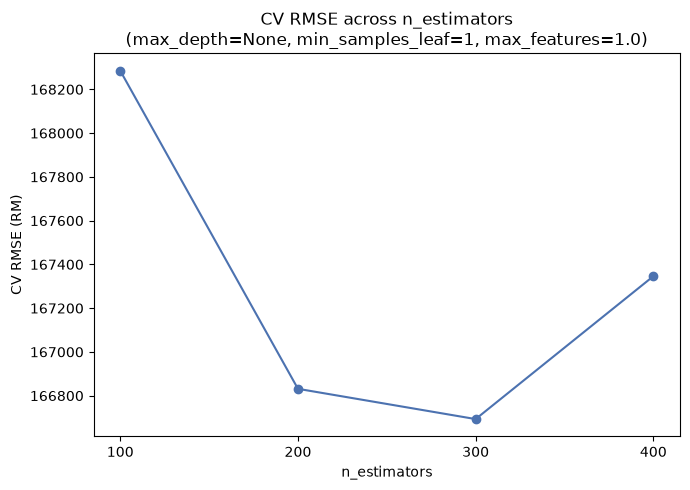

n_estimators=100: CV RMSE=RM168,285
n_estimators=200: CV RMSE=RM166,831
n_estimators=300: CV RMSE=RM166,693
n_estimators=400: CV RMSE=RM167,346


In [10]:
best = grid_search.best_params_
n_estimators_candidates = [100, 200, 300, 400]
cv_rmse_by_n = []

for n in n_estimators_candidates:
    if n == best["n_estimators"]:
        cv_rmse_by_n.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=n, max_depth=best["max_depth"], min_samples_leaf=best["min_samples_leaf"], max_features=best["max_features"], random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_n.append(cv["mean"]["RMSE"])

plt.figure(figsize=(7, 5))
plt.plot([str(n) for n in n_estimators_candidates], cv_rmse_by_n, marker="o", color="#4c72b0")
plt.xlabel("n_estimators")
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across n_estimators\n(max_depth={best['max_depth']}, min_samples_leaf={best['min_samples_leaf']}, max_features={best['max_features']})")
plt.tight_layout()
plt.show()

for n, r in zip(n_estimators_candidates, cv_rmse_by_n):
    print(f"n_estimators={n}: CV RMSE=RM{r:,.0f}")


## Checking the min_samples_leaf Effect

`min_samples_leaf` was also swept across its candidate values (holding `n_estimators=400`, `max_depth=20`, `max_features=0.5` fixed), evaluated using 5-fold CV RMSE on `X_train` only, to check whether it shows a pattern worth visualizing separately.

5-fold CV (mean +/- std):
  RMSE:  RM 170,226 +/- 25,096  (48.4% of median price)
  MAE:   RM 79,008 +/- 3,112
  MAPE:  19.5% +/- 1.6%
  R2:    0.7204 +/- 0.0663


5-fold CV (mean +/- std):
  RMSE:  RM 173,118 +/- 24,562  (49.2% of median price)
  MAE:   RM 80,921 +/- 3,665
  MAPE:  19.8% +/- 1.5%
  R2:    0.7121 +/- 0.0618


5-fold CV (mean +/- std):
  RMSE:  RM 176,371 +/- 25,761  (50.2% of median price)
  MAE:   RM 82,709 +/- 4,079
  MAPE:  20.2% +/- 1.4%
  R2:    0.7035 +/- 0.0527


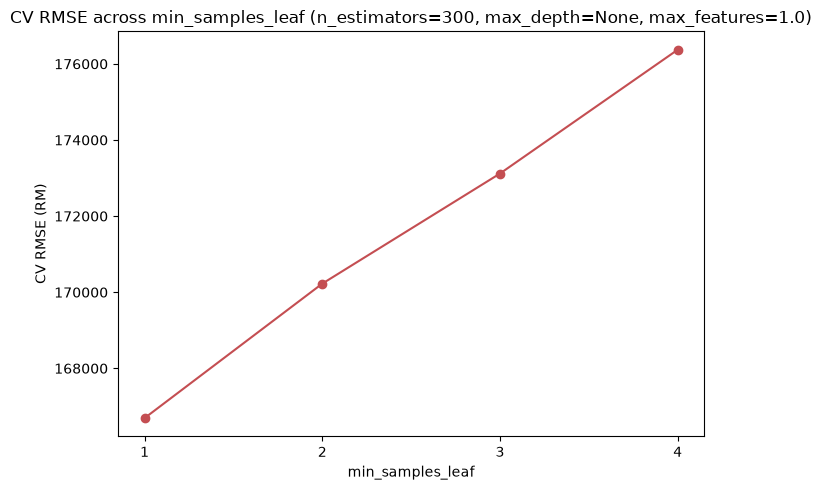

min_samples_leaf=1: CV RMSE=RM166,693
min_samples_leaf=2: CV RMSE=RM170,226
min_samples_leaf=3: CV RMSE=RM173,118
min_samples_leaf=4: CV RMSE=RM176,371


In [11]:
best = grid_search.best_params_
leaf_candidates = [1, 2, 3, 4]
cv_rmse_by_leaf = []

for l in leaf_candidates:
    if l == best["min_samples_leaf"]:
        cv_rmse_by_leaf.append(cv_results["mean"]["RMSE"])
        continue
    cv = cross_validate_model(
        RandomForestRegressor(n_estimators=best["n_estimators"], max_depth=best["max_depth"], min_samples_leaf=l, max_features=best["max_features"], random_state=42),
        X_train, y_train, n_splits=5,
    )
    cv_rmse_by_leaf.append(cv["mean"]["RMSE"])

plt.figure(figsize=(7, 5))
plt.plot([str(l) for l in leaf_candidates], cv_rmse_by_leaf, marker="o", color="#c44e52")
plt.xlabel("min_samples_leaf")
plt.ylabel("CV RMSE (RM)")
plt.title(f"CV RMSE across min_samples_leaf (n_estimators={best['n_estimators']}, max_depth={best['max_depth']}, max_features={best['max_features']})")
plt.tight_layout()
plt.show()

for l, r in zip(leaf_candidates, cv_rmse_by_leaf):
    print(f"min_samples_leaf={l}: CV RMSE=RM{r:,.0f}")
